In [2]:
%matplotlib inline  
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.sparse import diags

# *Diferencias Finitas para la Ecuación del Calor*

Para la ecuación del calor
$$
\frac{\partial u(t,x)}{\partial t} - \frac{\partial^2 u(t,x)}{\partial x^2} = 0
$$
para $t \in (0,T)$ y $x \in [L_{min},L_{max}]$, con condición inicial
$$
u(0,x) = U_0(x)
$$
y condiciones de contorno Dirichlet
$$
u(t,L_{min}) = U_{L_{min}}(t), \;\ u(t,L_{max}) = U_{L_{max}}(t) 
$$



**Ejemplo 1**

Dominio
$$
[0,T] \times [L_{min},L_{max}] = [0,1] \times [0,1]
$$
Condición inicial
$$
U_0(x) = \begin{cases}
0 \quad \text{si} \quad x<0,25\,\, \text{o} \,\, x>0,75\\
1 \quad \text{si} \quad 0,25 \leq x \leq 0,75
\end{cases}
$$
Condiciones de contorno
$$
U_{L_{min}}(t) = U_{L_{max}}(t) = 0 \quad \text{para todo}\,\,t\,.
$$



In [3]:
def Utmin(x): # Condicion inicial
    if (x<0.25) and (x>0.75):
        return 0.0
    else:
        return 1.0
    
def ULmax(t): # Condición de contorno derecha
    return 0.0
    
def ULmin(t): # Condición de contorno izquiera
    return 0.0
    

## Esquema de diferencias finitas explícito

In [4]:
def diffusion_explicit(Lmin,Lmax,m,tmin,tmax,n):
    # definir la red(x_mesh, t_mesh), dt, dx, alpha
    x_mesh = np.linspace(Lmin, Lmax, m)
    t_mesh = np.linspace(tmin, tmax, n)
    dt     = t_mesh[1]-t_mesh[0]
    dx     = x_mesh[1]-x_mesh[0]
    alpha  = dt/(dx*dx)

    # Inicializamos U (malla de soluciones) con ceros
    U = np.zeros([n,m])

    # Definimos la condicion inicial (U[0,j]) para todo j y condiciones de contorno para U (U[i,0], U[i,m-1]) para todo i
    for j in range(0,m):
        U[0,j] = Utmin(x_mesh[j]) # Valores iniciales con t=0

    for i in range(0,n):
        U[i,0] = ULmin(t_mesh[i]) # Condiciones de contorno x mínima

    for i in range(0,n): # Condiciones de contorno x máximo
        U[i,m-1] = ULmax(t_mesh[i])
    
    # Definir U en i+1 sabiendo su valor en i
    for i in range(1,n): # time (ya sabemos el valor de U en i=0)
        for j in range(1,m-1): # space (ya sabemos el valor de U en j=0 y j=m-1)
            U[i,j] = alpha*U[i-1, j-1] + (1-2*alpha)*U[i-1, j] + alpha*U[i-1, j+1]

    return U,x_mesh,t_mesh,alpha

### Aplicación esquema explícito (estable)

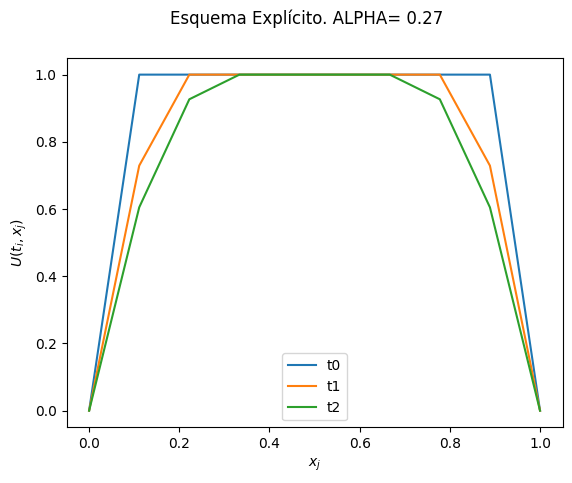

Text(0.5, 0, '$U(t_i,x_j)$')

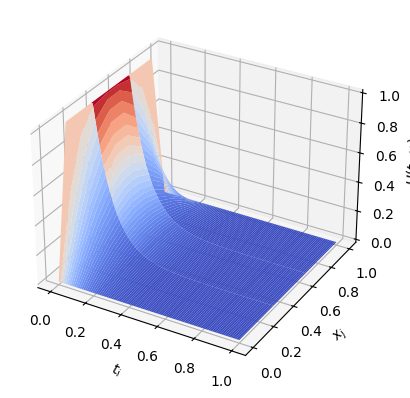

In [5]:
# Parámetros
Lmin, Lmax, tmin, tmax = 0, 1, 0, 1
m, n = 10, 300

Usol,x_mesh,t_mesh, alpha = diffusion_explicit(Lmin,Lmax,m,tmin,tmax,n)

# Gráfico en 2D
plt.plot(x_mesh,Usol[0,:],label="t0")
plt.plot(x_mesh,Usol[1,:],label="t1")
plt.plot(x_mesh,Usol[2,:],label="t2")
plt.xlabel('$x_j$')
plt.ylabel('$U(t_i,x_j)$')
plt.legend(loc="best")
plt.suptitle("Esquema Explícito. ALPHA= {0:.2f}".format(alpha))
plt.show()

# Gráfico en 3D
X, Y = np.meshgrid(x_mesh, t_mesh)
fig2 = plt.figure()
ax2  = fig2.add_subplot(111, projection='3d')
ax2.plot_surface( Y,X, Usol,rstride=3, cstride=3,cmap=plt.cm.coolwarm)
ax2.set_ylabel('$x_j$')
ax2.set_xlabel('$t_i$')
ax2.set_zlabel('$U(t_i,x_j)$')

### Aplicación esquema explícito (inestable)

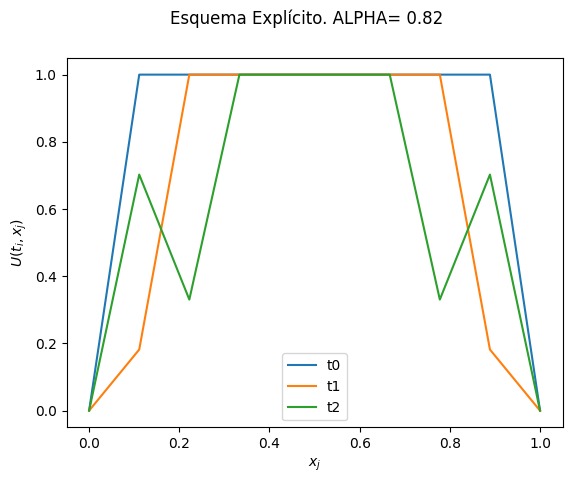

Text(0.5, 0, '$U(t_i,x_j)$')

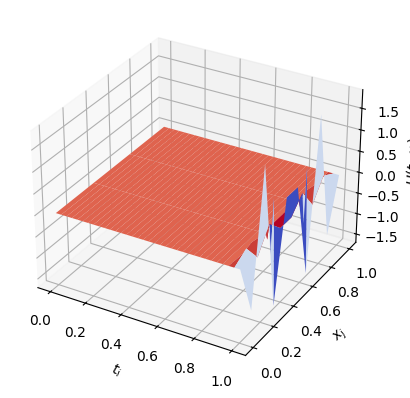

In [6]:
# Parámetros
Lmin, Lmax, tmin, tmax = 0, 1, 0, 1
m, n = 10, 100

Usol,x_mesh,t_mesh, alpha = diffusion_explicit(Lmin,Lmax,m,tmin,tmax,n)

# Gráfico en 2D
plt.plot(x_mesh,Usol[0,:],label="t0")
plt.plot(x_mesh,Usol[1,:],label="t1")
plt.plot(x_mesh,Usol[2,:],label="t2")
plt.xlabel('$x_j$')
plt.ylabel('$U(t_i,x_j)$')
plt.legend(loc="best")
plt.suptitle("Esquema Explícito. ALPHA= {0:.2f}".format(alpha))
plt.show()

# Gráfico en 3D
X, Y = np.meshgrid(x_mesh, t_mesh)
fig2 = plt.figure()
ax2  = fig2.add_subplot(111, projection='3d')
ax2.plot_surface( Y,X, Usol,rstride=3, cstride=3,cmap=plt.cm.coolwarm)
ax2.set_ylabel('$x_j$')
ax2.set_xlabel('$t_i$')
ax2.set_zlabel('$U(t_i,x_j)$')

## Esquema Implicito

In [7]:
def diffusion_implicit(Lmin,Lmax,m,tmin,tmax,n):

    # definir la red(x_mesh, t_mesh), dt, dx, alpha
    x_mesh = np.linspace(Lmin, Lmax, m)
    t_mesh = np.linspace(tmin, tmax, n)
    dt     = t_mesh[1]-t_mesh[0]
    dx     = x_mesh[1]-x_mesh[0]
    alpha  = dt/(dx*dx)
    
    # Inicializamos U
    U = np.zeros([n,m])
    # Definimos la condicion inicial (U[0,j]) para todo j y condiciones de contorno para U (U[i,0], U[i,m-1]) para todo i
    for j in range(0,m):
        U[0,j] = Utmin(x_mesh[j]) # Valores iniciales con t=0

    for i in range(0,n): # Condiciones de contorno x mínima
        U[i,0] = ULmin(t_mesh[i]) 
    for i in range(0,n): # Condiciones de contorno x máximo
        U[i,-1] = ULmax(t_mesh[i])
    
    # definir el sistema lineal (Habrá que resolver un sistema lineal para cada tiempo i)
    # definimos M, que es invariante con respecto al tiempo con el comando diags
    M = diags([-alpha, 1+2*alpha, -alpha], # Valores de las diagonales
              [-1, 0, 1], # "Posiciones" de las diagonales relativas al centro
              shape=(m-2, m-2) # Tamaño de la matriz (m-2)x(m-2) porque ya sabemos el valor de U en los extremos
              ).toarray()
    
    # para cada tiempo i, definimos el vector b^i y resolvemos el sistema M·u_{i+1}=b_i para hallar u_{i+1}
    for i in range(1,n): # tiempo

        # Definimos la matriz b
        b = U[i-1, 1:m-1].copy() # barra en tiempo anterior menos los extremos
        b[0] += alpha*U[i, 0]
        b[-1] += alpha* U[i, -1]

        # Resolvemos el sistema lineal
        U[i, 1:m-1] = np.linalg.solve(M, b)


    return U,x_mesh,t_mesh,alpha

### Aplicación esquema implícito

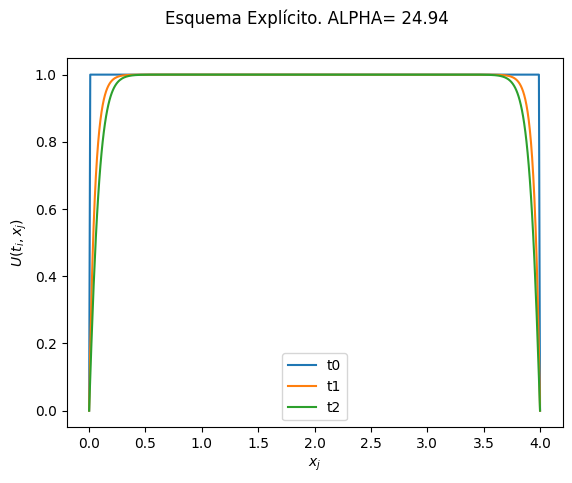

Text(0.5, 0, '$U(t_i,x_j)$')

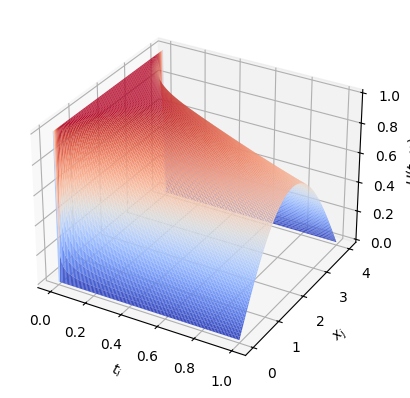

In [ ]:
# Parameters
Lmin, Lmax, tmin, tmax = 0, 4, 0, 1
m, n = 400, 400

Usol,x_mesh,t_mesh, alpha= diffusion_implicit(Lmin,Lmax,m,tmin,tmax,n)

# Gráfico en 2D
plt.plot(x_mesh,Usol[0,:],label="t0")
plt.plot(x_mesh,Usol[1,:],label="t1")
plt.plot(x_mesh,Usol[2,:],label="t2")
plt.xlabel('$x_j$')
plt.ylabel('$U(t_i,x_j)$')
plt.legend(loc="best")
plt.suptitle("Esquema Explícito. ALPHA= {0:.2f}".format(alpha))
plt.show()

# Gráfico en 3D
X, Y = np.meshgrid(x_mesh, t_mesh)
fig2 = plt.figure()
ax2  = fig2.add_subplot(111, projection='3d')
ax2.plot_surface( Y,X, Usol,rstride=3, cstride=3,cmap=plt.cm.coolwarm)
ax2.set_ylabel('$x_j$')
ax2.set_xlabel('$t_i$')
ax2.set_zlabel('$U(t_i,x_j)$')

## Crank Nicolson

In [9]:
def diffusion_cn(Lmin,Lmax,m,tmin,tmax,n):
    
    # definir la red(x_mesh, t_mesh), dt, dx, alpha
    x_mesh = np.linspace(Lmin, Lmax, m)
    t_mesh = np.linspace(tmin, tmax, n)
    dt     = t_mesh[1]-t_mesh[0]
    dx     = x_mesh[1]-x_mesh[0]
    alpha  = dt/(dx*dx)
    
    # Inicializamos U
    U = np.zeros([n,m])
    # Definimos la condicion inicial (U[0,j]) para todo j y condiciones de contorno para U (U[i,0], U[i,m-1]) para todo i
    for j in range(0,m):
        U[0,j] = Utmin(x_mesh[j]) # Valores iniciales con t=0
    for i in range(0,n):
        U[i,0] = ULmin(t_mesh[i]) # Condiciones de contorno x mínima
    for i in range(0,n): # Condiciones de contorno x máximo
        U[i,m-1] = ULmax(t_mesh[i])

    # definir sistema lineal
    # M y N independientes del tiempo, con el comando diags
    M = diags([-alpha*0.5, 1+alpha, -alpha*0.5], [-1, 0, 1], shape=(m-2, m-2)).toarray()
    N = diags([alpha*0.5, 1-alpha, alpha*0.5], [-1, 0, 1], shape=(m-2, m-2)).toarray() 
     
    for i in range(1,n): # tiempo
        b = np.dot(N, U[i-1, 1:m-1])
        b[0] += alpha*0.5*(U[i, 0]+U[i-1, 0])
        b[-1] += alpha*0.5*(U[i, -1]+U[i-1, -1])
        U[i, 1:m-1] = np.linalg.solve(M, b)
    return U,x_mesh,t_mesh,alpha

### Aplicación esquema Cranck-Nicolson

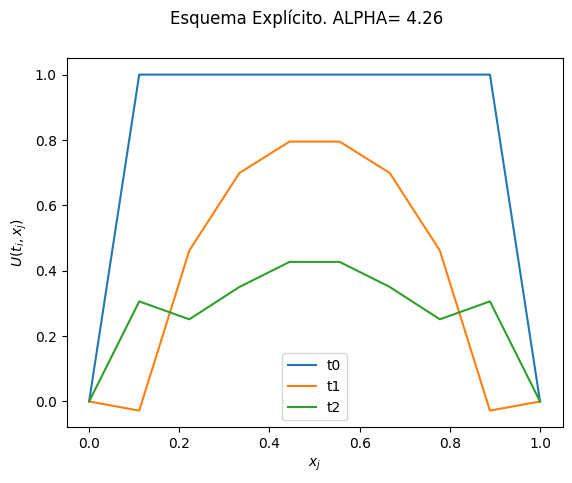

Text(0.5, 0, '$U(t_i,x_j)$')

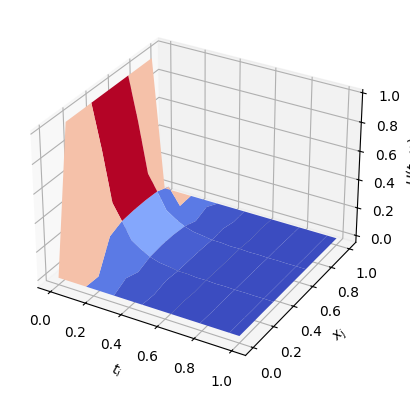

In [10]:
# Parameters
Lmin, Lmax, tmin, tmax = 0, 1, 0, 1
m, n = 10, 20

Usol,x_mesh,t_mesh, alpha= diffusion_cn(Lmin,Lmax,m,tmin,tmax,n)

# Gráfico en 2D
plt.plot(x_mesh,Usol[0,:],label="t0")
plt.plot(x_mesh,Usol[1,:],label="t1")
plt.plot(x_mesh,Usol[2,:],label="t2")
plt.xlabel('$x_j$')
plt.ylabel('$U(t_i,x_j)$')
plt.legend(loc="best")
plt.suptitle("Esquema Explícito. ALPHA= {0:.2f}".format(alpha))
plt.show()

# Gráfico en 3D
X, Y = np.meshgrid(x_mesh, t_mesh)
fig2 = plt.figure()
ax2  = fig2.add_subplot(111, projection='3d')
ax2.plot_surface( Y,X, Usol,rstride=3, cstride=3,cmap=plt.cm.coolwarm)
ax2.set_ylabel('$x_j$')
ax2.set_xlabel('$t_i$')
ax2.set_zlabel('$U(t_i,x_j)$')

## Esquema genérico: $\theta$\-esquema

In [11]:
def diffusion_theta(theta,Lmin,Lmax,m,tmin,tmax,n):
    # definir la red(x_mesh, t_mesh), dt, dx, alpha
    x_mesh = np.linspace(Lmin, Lmax, m)
    t_mesh = np.linspace(tmin, tmax, n)
    dt     = t_mesh[1]-t_mesh[0]
    dx     = x_mesh[1]-x_mesh[0]
    alpha  = dt/(dx*dx)
    
    # Inicializamos U
    U = np.zeros([n,m])
    # Definimos la condicion inicial (U[0,j]) para todo j y condiciones de contorno para U (U[i,0], U[i,m-1]) para todo i
    for j in range(0,m):
        U[0,j] = Utmin(x_mesh[j]) # Valores iniciales con t=0
    for i in range(0,n):
        U[i,0] = ULmin(t_mesh[i]) # Condiciones de contorno x mínima
    for i in range(0,n): # Condiciones de contorno x máximo
        U[i,m-1] = ULmax(t_mesh[i])
            
    # definir sistema lineal
    # M y N independientes del tiempo, con el comando diags
    # Coeficientes para la matriz M (lado izquierdo, t+1)
    diag_M_center = 1 + 2*alpha*theta
    diag_M_side   = -alpha*theta
    
    # Coeficientes para la matriz N (lado derecho, t)
    diag_N_center = 1 - 2*alpha*(1-theta)
    diag_N_side   = alpha*(1-theta)

    M = diags([diag_M_side, diag_M_center, diag_M_side], [-1, 0, 1], shape=(m-2, m-2)).toarray()
    N = diags([diag_N_side, diag_N_center, diag_N_side], [-1, 0, 1], shape=(m-2, m-2)).toarray() 
     
#     print("M",M)
#     print("N",N)
    
    for i in range(1,n): # tiempo
        # Vector b (lado derecho)
        # b = N * U_interior_anterior
        u_prev_interior = U[i-1, 1:m-1]
        b = np.dot(N, u_prev_interior)
        
        # Añadir condiciones de contorno al vector b
        # Lado izquierdo (j=0)
        b[0] += alpha * theta * U[i,0] + alpha * (1-theta) * U[i-1,0]
        # Lado derecho (j=m-1)
        b[-1] += alpha * theta * U[i,m-1] + alpha * (1-theta) * U[i-1,m-1]
        
        # Resolvemos el sistema M * U_interior_actual = b
        U[i, 1:m-1] = np.linalg.solve(M, b)
    
    return U,x_mesh,t_mesh,alpha

### Aplicación $\theta$ - método

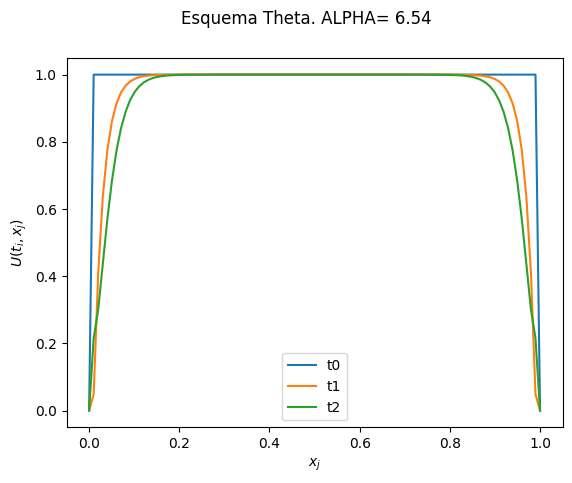

Text(0.5, 0, '$U(t_i,x_j)$')

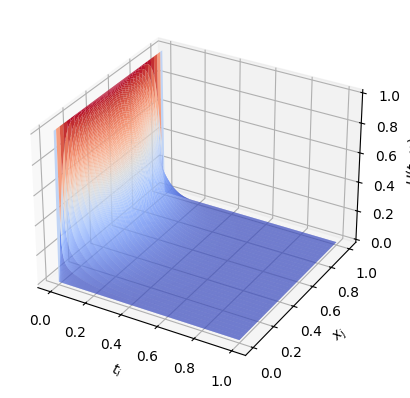

In [12]:
# Parameters
Lmin, Lmax, tmin, tmax = 0, 1, 0, 1
m, n = 100, 1500
theta = 0.65

Usol,x_mesh,t_mesh, alpha= diffusion_theta(theta,Lmin,Lmax,m,tmin,tmax,n)

# Gráfico en 2D
plt.plot(x_mesh,Usol[0,:],label="t0")
plt.plot(x_mesh,Usol[1,:],label="t1")
plt.plot(x_mesh,Usol[2,:],label="t2")
plt.xlabel('$x_j$')
plt.ylabel('$U(t_i,x_j)$')
plt.legend(loc="best")
plt.suptitle("Esquema Theta. ALPHA= {0:.2f}".format(alpha))
plt.show()

# Gráfico en 3D
X, Y = np.meshgrid(x_mesh, t_mesh)
fig2 = plt.figure()
ax2  = fig2.add_subplot(111, projection='3d')
ax2.plot_surface( Y,X, Usol,rstride=3, cstride=3,cmap=plt.cm.coolwarm)
ax2.set_ylabel('$x_j$')
ax2.set_xlabel('$t_i$')
ax2.set_zlabel('$U(t_i,x_j)$')